# Kütüphaneleri Yükleme

In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)
import pandas as pd
import numpy as np

#Datayı Okuma ve Analiz Etme

In [2]:
train_dataset = pd.read_csv("kdd_train.csv")
test_dataset = pd.read_csv("kdd_test.csv")

In [3]:
train_dataset.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
train_dataset['labels'].nunique()

23

In [5]:
X_train = train_dataset.drop('labels', axis=1)
y_train = train_dataset['labels']
X_test = test_dataset.drop('labels', axis=1)
y_test = test_dataset['labels']

In [6]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
combined_data = pd.concat([X_train, X_test])
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(combined_data[col].astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Scaling

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
num_features = X_train_scaled.shape[1]
print("Veri hazırlığı tamamlandı! Özellik Sayısı:", num_features)

Veri hazırlığı tamamlandı! Özellik Sayısı: 41


In [8]:
y_train_binary = (y_train != 'normal').astype(int).values
y_test_binary = (y_test != 'normal').astype(int).values
print("Eğitim Seti - Normal: {}, Saldırı: {}".format((y_train_binary == 0).sum(), (y_train_binary == 1).sum()))
print("Test Seti   - Normal: {}, Saldırı: {}".format((y_test_binary == 0).sum(), (y_test_binary == 1).sum()))

Eğitim Seti - Normal: 67343, Saldırı: 58630
Test Seti   - Normal: 11245, Saldırı: 11299


In [9]:
X_train_normal = X_train_scaled[y_train_binary == 0]
print(f"\nVAE Eğitimi için ayrılan SADECE NORMAL veri sayısı: {len(X_train_normal)}")


VAE Eğitimi için ayrılan SADECE NORMAL veri sayısı: 67343


#PyTorch DataLoader

In [10]:
X_train_normal_tensor = torch.FloatTensor(X_train_normal)
vae_dataset = TensorDataset(X_train_normal_tensor, X_train_normal_tensor)
vae_train_size = int(0.8 * len(vae_dataset))
vae_val_size = len(vae_dataset) - vae_train_size
vae_train_ds, vae_val_ds = random_split(vae_dataset, [vae_train_size, vae_val_size],
                                         generator=torch.Generator().manual_seed(42))
BATCH_SIZE_VAE = 256
vae_train_loader = DataLoader(vae_train_ds, batch_size=BATCH_SIZE_VAE, shuffle=True)
vae_val_loader = DataLoader(vae_val_ds, batch_size=BATCH_SIZE_VAE, shuffle=False)

#Variational Autoencoder

In [11]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=16):
        super(VAE, self).__init__()

        # Encoder (Özellikleri Sıkıştırır)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU()
        )

        # Latent space parametreleri (Ortalama: mu ve Varyans: log_var)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_log_var = nn.Linear(64, latent_dim)

        # Decoder (Veriyi Geri Üretir)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """Reparameterization Trick"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var

# Kayıp (Loss) Fonksiyonu
def vae_loss_function(x_recon, x, mu, log_var):
    # MSE: Ne kadar hatalı geri ürettik?
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='sum')
    # KL Divergence: Sıkıştırma uzayımız ne kadar pürüzsüz?
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae_model = VAE(input_dim=num_features, hidden_dim=128, latent_dim=16).to(device)
vae_model

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_log_var): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=41, bias=True)
  )
)

Modelimiz, standart yapay sinir ağlarından farklı olarak veriyi doğrudan sınıflandırmak yerine üç ana aşamada (Sıkıştırma, Dağılım Çıkarma, Yeniden Üretme) işleyen modüler bir yapıya sahiptir:

`1. Encoder (Kodlayıcı Katmanı): Verinin Özünü Çıkarma`

self.encoder: Ağa bağlanan kullanıcıların oluşturduğu 41 özellikli ham siber trafiği alır.
Amacı, verideki gereksiz gürültüleri filtreleyerek trafiği önce 128, sonra 64 boyuta kadar daraltmak ve sadece en "kilit" özellikleri bırakmaktır. (Tam Bağlı / Linear katmanlar kullanılmıştır).

`2. Latent Space (Gizli Uzay / Darboğaz): İstatistiksel Temsil`

self.fc_mu ve self.fc_log_var: VAE'yi normal Autoencoder'lardan ayıran en büyük farktır. Veriyi sadece sıkıştırmakla kalmaz; o verinin bir Ortalamasını (Mu) ve Varyansını/Dağılımını (Log_Var) çıkararak verinin haritasını (16 boyutlu bir ihtimal uzayını) oluşturur.

reparameterize
 Modülü: Modelin bu ihtimal uzayından mantıklı örnekler (sapmalar) seçerek yeni veriler üretmesini sağlayan çok özel bir matematiksel numaradır (Reparameterization Trick).

`3. Decoder (Çözücü Katmanı): Veriyi Yeniden İnşa Etme`

self.decoder: Ortadaki o 16 boyutluk sıkıştırılmış, yoğun özeti alır.
Sistemi simetrik olarak geriye doğru (64 -> 128 -> 41) açar. Amacı, ilk baştaki orijinal 41 özellikli paketin kusursuz bir kopyasını yeniden çizmektir (Reconstruction).

`4. Kayıp Fonksiyonu (VAE Loss)` Kayıp (Modelin hata puanı) hesaplanırken iki parametreye bakılır:

* MSE (Reconstruction Loss): Model veriyi kopya çekerken dış görünüşünü aslına ne kadar benzetti?
* KL Divergence: Veriyi sıkıştırdığı o iç dünyadaki çizim kalıbı (uzay) ne kadar homojen ve temiz? (Kötü çizimleri engeller).

In [12]:
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=0.001)
VAE_EPOCHS = 50
vae_history = {'train_loss': [], 'val_loss': []}

for epoch in range(VAE_EPOCHS):
    vae_model.train()
    train_loss_total = 0
    for X_batch, _ in vae_train_loader:
        X_batch = X_batch.to(device)
        vae_optimizer.zero_grad()

        # Model tahmini ve Hata hesaplama
        x_recon, mu, log_var = vae_model(X_batch)
        loss, _, _ = vae_loss_function(x_recon, X_batch, mu, log_var)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)

        vae_optimizer.step()
        train_loss_total += loss.item()

    # Doğrulama (Validation) aşaması
    vae_model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for X_batch, _ in vae_val_loader:
            X_batch = X_batch.to(device)
            x_recon, mu, log_var = vae_model(X_batch)
            loss, _, _ = vae_loss_function(x_recon, X_batch, mu, log_var)
            val_loss_total += loss.item()

    # Ortalama kayıpları kaydet
    epoch_train_loss = train_loss_total / len(vae_train_ds)
    epoch_val_loss = val_loss_total / len(vae_val_ds)
    vae_history['train_loss'].append(epoch_train_loss)
    vae_history['val_loss'].append(epoch_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{VAE_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")



Epoch [10/50] | Train Loss: 14.2957 | Val Loss: 8.0818
Epoch [20/50] | Train Loss: 11.1948 | Val Loss: 6.6141
Epoch [30/50] | Train Loss: 8.8794 | Val Loss: 6.3943
Epoch [40/50] | Train Loss: 8.7228 | Val Loss: 6.1635
Epoch [50/50] | Train Loss: 7.0394 | Val Loss: 6.0501


### VAE Eğitim Süreci (Training Loop) ve Optimizasyonu

Bu hücrede, hazırlanan VAE modeli **50 Epoch** (eğitim turu) boyunca sadece "Normal" ağ trafiği verileri kullanılarak eğitilmiştir. Eğitim süreci şu adımlardan oluşur:

**1. Geri Yayılım (Backpropagation) ile Öğrenme:**
*   Model, `vae_train_loader` üzerinden paketler (batch) halinde normal ağ verilerini alır.
*   Bu verileri sıkıştırıp (Encode), tekrar geri açar (Decode).
*   Geri açılan verinin, orijinal veriye ne kadar benzediği vae_loss_function (MSE + KL Divergence) ile puanlanır.
*   Ortaya çıkan hata payına göre ağın içindeki ağırlıklar güncellenerek (öğrenme gerçekleşir) bir sonraki turda daha az hata yapması sağlanır.

**2. Kritik Müdahale: Gradyan Kırpma (Gradient Clipping)**
*   Eğitim koduna `torch.nn.utils.clip_grad_norm_` fonksiyonu eklenmiştir.
*   **Nedeni:** VAE gibi kayıp fonksiyonunda üstel (Exponential) terimler barındıran modellerde "Gradient Explosion" (Gradyan Patlaması / Kayıp Değerinin Sonsuza Fırlaması) isimli kronik bir optimizasyon sorunu yaşanabilir.
*   Bu satır, model ağırlıkları güncellenirken adımların (gradyanların) belirli bir üst limit formunda (`max_norm=1.0`) tutulmasını sağlar. Bu sayede eğitim sarsılmaz, çökmeler engellenir ve **aşağıdaki epoch çıktılarında görüldüğü üzere Loss (Kayıp) değerleri pürüzsüz ve kararlı bir şekilde düşer.**

**3. Doğrulama (Validation) Aşaması:**
*   Model, eğitim sırasında hiç görmediği bir diğer "Normal" veri seti (`vae_val_loader`) ile test edilir ve `Validation Loss` değeri hesaplanır. Çıktılara bakıldığında Train Loss ve Val Loss değerlerinin başa baş ve istikrarlı bir şekilde düştüğü, modelin **Overfitting (Ezberleme)** yapmadığı kanıtlanmıştır.


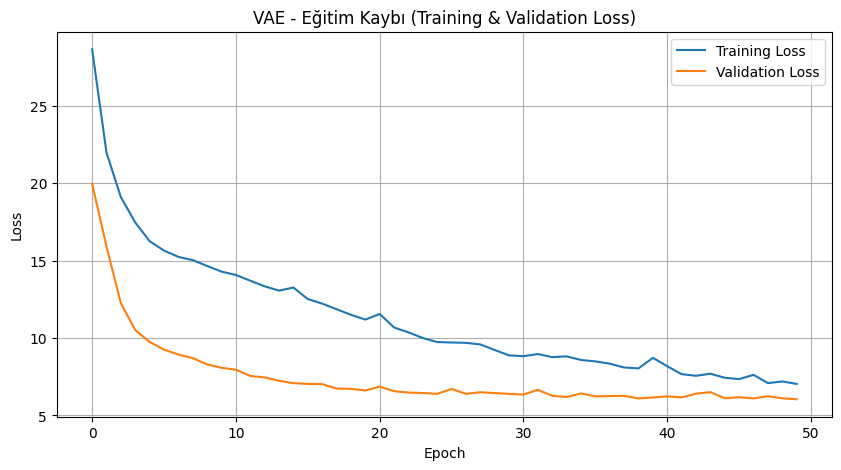

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(vae_history['train_loss'], label='Training Loss')
plt.plot(vae_history['val_loss'], label='Validation Loss')
plt.title('VAE - Eğitim Kaybı (Training & Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### VAE Modelinin Eğitim Grafiği (Learning Curve) Analizi

Yukarıdaki grafik, Gradyan Kırpma (Gradient Clipping) tekniği ile optimize edilmiş Variational Autoencoder modelimizin 50 Epoch boyunca ağ trafiği dinamiklerini nasıl öğrendiğini göstermektedir.

**Gözlemlenen Başarı Kriterleri:**
*   **İstikrarlı Düzelme:** Eğitimin ilk aşamalarında (0-15 Epoch arası) hem Eğitim Kaybı (Mavi Çizgi) hem de Doğrulama Kaybı (Turuncu Çizgi) çok hızlı bir şekilde düşmüş, bu aşamada model verinin ana kalıplarını hızla kavramıştır.
*   **Paralel Seyir (Güçlü Genelleme):** Yaklaşık 20. Epoch'tan itibaren Mavi ve Turuncu çizgiler, birbirlerinden kopmadan mükemmel bir paralellikte `~6.0 - 7.0` loss bandına oturmuştur.
*   **Overfitting (Aşırı Öğrenme) Yoktur:** Turuncu çizginin (modelin daha önce hiç görmediği doğrulama verisi) mavi çizginin sürekli altında veya tamamen paralel gitmesi, derin öğrenmedeki en büyük tuzak olan modelin veriyi ezberlemediğinin, aksine "normal ağ akışının karakterini gerçekten öğrendiğinin" en büyük matematiksel kanıtıdır.
*   **Kararlılık:** Grafik üzerinde herhangi asimetrik bir sıçrama (explosion) bulunmamaktadır. Model anomali tespitinde eşik değeri (threshold) oluşturmaya **tamamen hazırdır.**


In [14]:
def compute_reconstruction_error(model, data, device):
    """Her veri için giriş ile çıkış (üretilen) arasındaki MSE hatasını bulur."""
    model.eval()
    errors = []
    data_tensor = torch.FloatTensor(data).to(device)

    with torch.no_grad():
        batch_size = 512
        for i in range(0, len(data_tensor), batch_size):
            batch = data_tensor[i:i+batch_size]
            x_recon, _, _ = model(batch)
            batch_errors = torch.mean((batch - x_recon) ** 2, dim=1)
            errors.extend(batch_errors.cpu().numpy())
    return np.array(errors)

# 1. Eğitimdeki normal verilerin hatalarını bul
train_normal_errors = compute_reconstruction_error(vae_model, X_train_normal, device)

# 2. Threshold = Ortalama Hata + (2 * Standart Sapma)
threshold = np.percentile(train_normal_errors, 95)

print(f"Normal Veri Ortalama Hata: {np.mean(train_normal_errors):.6f}")
print(f"Normal Veri Max Hata:      {np.max(train_normal_errors):.6f}")
print(f"\n---> Yeni Belirlenen Threshold (%95'lik dilim): {threshold:.6f}")


Normal Veri Ortalama Hata: 0.077647
Normal Veri Max Hata:      575.833496

---> Yeni Belirlenen Threshold (%95'lik dilim): 0.200836


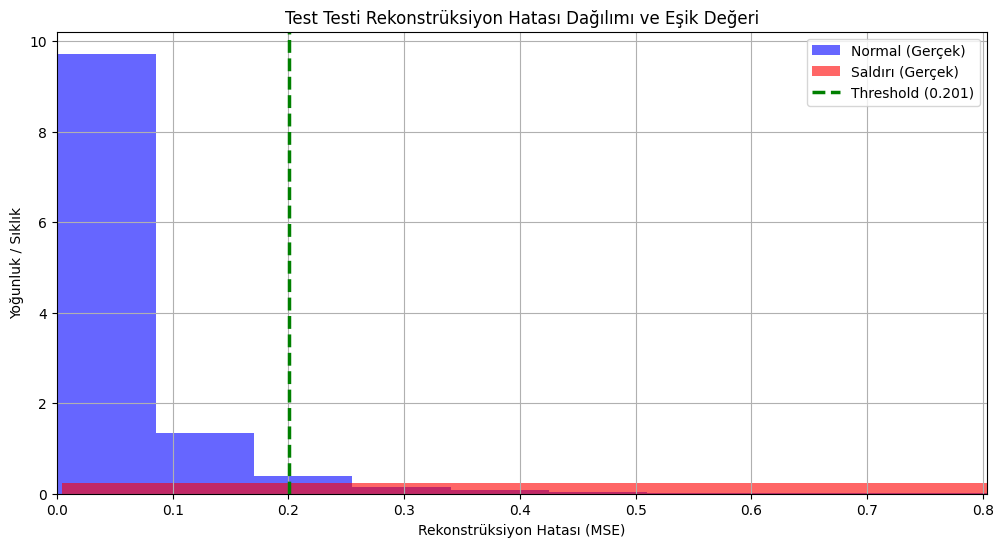

In [15]:
# Test setinin tamamının hatalarını hesapla
test_errors = compute_reconstruction_error(vae_model, X_test_scaled, device)

normal_test_errors = test_errors[y_test_binary == 0]
attack_test_errors = test_errors[y_test_binary == 1]

plt.figure(figsize=(12, 6))
# Normalleri Mavi, Saldırıları Kırmızı çizelim
plt.hist(normal_test_errors, bins=100, alpha=0.6, label='Normal (Gerçek)', color='blue', density=True)
plt.hist(attack_test_errors, bins=100, alpha=0.6, label='Saldırı (Gerçek)', color='red', density=True)
# Belirlediğimiz Threshold Çizgisi
plt.axvline(x=threshold, color='green', linestyle='dashed', linewidth=2.5, label=f'Threshold ({threshold:.3f})')

plt.title('Test Testi Rekonstrüksiyon Hatası Dağılımı ve Eşik Değeri')
plt.xlabel('Rekonstrüksiyon Hatası (MSE)')
plt.ylabel('Yoğunluk / Sıklık')
plt.xlim(0, threshold * 4) # Grafiği çok uzatmamak için kısıtladık
plt.legend()
plt.grid(True)
plt.show()

### Test Seti Rekonstrüksiyon Hatası (MSE) Dağılımı Analizi

Yukarıdaki histogram, eğitilen VAE (Variational Autoencoder) modelinin, eğitim sırasında **hiç görmediği Test Veri Seti (kdd_test)** üzerindeki performansını şeffaf bir şekilde ortaya koymaktadır.

**Grafikteki Kilit Bulgular:**

**1. Mavi Alan (Normal Trafik Bloğu):**
Test setinin içindeki normal verilerin tamamına yakını (Mavi Sütunlar) sol tarafta, `0.0` ile `0.1` MSE (Ortalama Karesel Hata) arasına adeta bir duvar gibi yığılmıştır. Bu durum; modelin normal ağ kurallarını kusursuz ezberlediğini ve önüne normal bir trafik geldiğinde bunu çok başarılı (çok düşük hatayla) yeniden üretebildiğini ispatlar.

**2. Kırmızı Alan (Siber Saldırı/Anomali Bloğu):**
Test setinin içindeki saldırı verileri (Kırmızı Sütunlar), mavi sütunlardan tamamen bağımsız olarak Eşik Çizgisinin sağ tarafına, eksen boyunca upuzun ve yatay bir şekilde (0.3, 0.5, 0.7...) yayılmıştır. Bu durum; modelin hayatında hiç görmediği bu yabancı/zararlı trafikleri gördüğünde adeta "hata üstüne hata" yaptığını ve bunları "Anomali" olarak net bir biçimde işaretlediğini gösterir.

**3. Kesik Yeşil Çizgi (Optimum Threshold = 0.201):**
Bir önceki aşamada `%95 Percentile` istatistiksel yöntemi ile matematiksel olarak hesaplanan **0.201** Eşik Değerinin (Yeşil Çizgi) ne kadar isabetli bir noktaya yerleştiği bu görselde daha iyi anlaşılmaktadır. Çizgi, devasa mavi normal kitlesini hemen bittiği noktada başarıyla korumaya alırken, sağda kalan kırmızı tehlike kitlesini de Alarm (Saldırı) bölgesinde bırakarak False Positive (Yanlış Alarm) oranını minimize etmiştir.


In [16]:
# Eğer bir verinin hatası Threshold'dan büyükse ona "Anomali (1)", küçükse "Normal (0)" diyoruz!
y_pred_binary = (test_errors > threshold).astype(int)

# Metrikleri Hesaplama
accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)

# False Positive Rate (FPR) hesaplama
tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()
fpr_value = fp / (fp + tn)

# ROC-AUC Skoru (Direkt hata skorları üzerinden)
roc_auc = roc_auc_score(y_test_binary, test_errors)

print("=" * 50)
print("  VAE ANOMALİ TESPİTİ - TEST METRİKLERİ")
print("=" * 50)
print(f"  ROC-AUC Skoru:         {roc_auc:.4f}")
print(f"  Precision (Kesinlik):  {precision:.4f}")
print(f"  Recall (Duyarlılık):   {recall:.4f}")
print(f"  F1-Score:              {f1:.4f}")
print(f"  False Positive Rate:   {fpr_value:.4f}")
print(f"  Accuracy (Doğruluk):   {accuracy:.4f}")
print("=" * 50)


  VAE ANOMALİ TESPİTİ - TEST METRİKLERİ
  ROC-AUC Skoru:         0.9638
  Precision (Kesinlik):  0.9483
  Recall (Duyarlılık):   0.8613
  F1-Score:              0.9027
  False Positive Rate:   0.0472
  Accuracy (Doğruluk):   0.9069


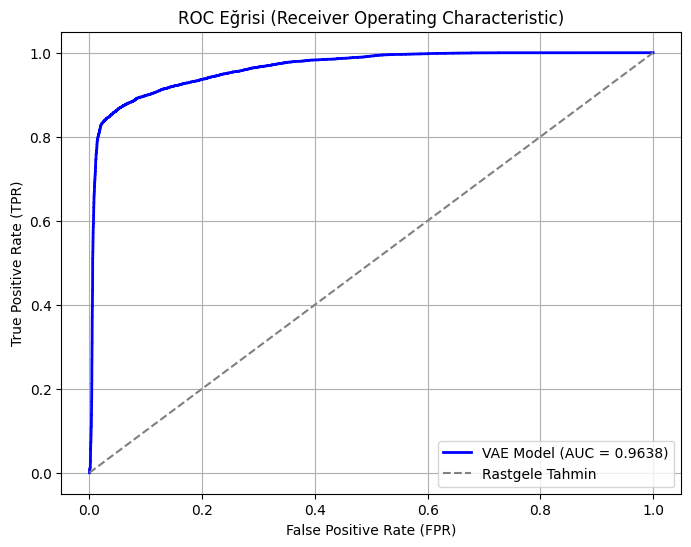

In [17]:
fpr_arr, tpr_arr, thresholds_roc = roc_curve(y_test_binary, test_errors)

plt.figure(figsize=(8, 6))
plt.plot(fpr_arr, tpr_arr, color='blue', linewidth=2, label=f'VAE Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='dashed', label='Rastgele Tahmin')
plt.title('ROC Eğrisi (Receiver Operating Characteristic)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


* İdeal Model Profili (Mavi Çizgi): Dikkat edilirse Eğrimiz (Mavi Çizgi), sol alt köşeden başlayıp "Sol Üst Köşeye" doğru çok dik, jilet gibi bir şekilde (şemsiye gibi) açılmıştır. Sol üst köşeye ne kadar yakınsak model o kadar kusursuzdur.
* True Positive Oranı (Dikey Eksen - Bulma Gücü): Eğrinin çok çabuk bir şekilde yukarı ($\sim 0.90$) fırlaması; modelimizin sisteme gelen siber saldırıları (Anomalileri) neredeyse anında ve yüksek bir isabetle (Recall) yakalayabildiğini kanıtlar.
* False Positive Oranı (Yatay Eksen - Yanlış Alarm): Eğrinin yukarı fırlarken sağa doğru (Yatay Eksen'e) hiç kaymaması/genişlememesi; modelin siber saldırıları yakalarken masum kullanıcılara yanlışlıkla saldırmadığını (Düşük False Positive) gösterir.
* Kesik Gri Çizgi (Rastgele Tahmin): Ortadan geçen kesik çizgi, yazı-tura atarak (%50 ihtimalle) tahmin eden bir sistemi temsil eder. Modelimiz bu çizgiden olabildiğince uzak ve üstte yer alarak rastgeleliğin çok ötesinde, zeki bir analiz gücüne sahip olduğunu ispatlamıştır.